# LFMM climate-GEA on SV Δp (gen3 vs SEEDMIX), structure-controlled

**Method (phase-1 pipeline).** `lfmm_ridge(Y=Δpᵀ, X=bio1, K)` then
`lfmm_test(calibrate="gif")` (R `lfmm`). Y = gen-3 `site_gen_plot` pool Δp for
**23,344 SVs** (MAF≥0.05 + min-count), X = standardized site temperature.

**Choosing K — the key finding.** Their old K=3 came from Tracy-Widom on a
231-sample founder matrix (TW flags every PC here → useless). Recomputing structure
from gen-3 SNPs gives a **flat scree (PC1=9.7%, no elbow)** and **|corr(PC1,bio1)|=0.41**
(structure partly tracks climate). So we pick K by **GIF calibration**. The GIF
barely responds to K and never approaches 1 — because the inflation is **not genetic
structure** but **pseudoreplication**: GIF(K=1)=3.11 = √(193 pools / 20 sites).
After honest calibration the genome-wide SV signal nearly vanishes. Displayed: K=6.


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
L = "/global/scratch/users/tbellg/kmate/results/grenenet_gea/lfmm"
GEA = "/global/scratch/users/tbellg/kmate/results/grenenet_gea/gea"
KDISP = 6
loci = pd.read_csv(f"{L}/locus_index_gen3_sv.csv")     # chrom,pos,...,rec_index (row-aligned)
def col0(p): d=pd.read_csv(p); return d[d.columns[0]].to_numpy()
cal = col0(f"{L}/kscan_bio1_k{KDISP}.calibrated_pval.csv")
unc = col0(f"{L}/kscan_bio1_k{KDISP}.pval.csv")
loci["cal_p"], loci["unc_p"] = cal, unc
gif = {K: float(open(f"{L}/kscan_bio1_k{K}.gif.txt").read()) for K in range(1,9)}
n_pools, n_sites = 193, 20
print("loci:", len(loci), "| GIF by K:", {k: round(v,2) for k,v in gif.items()})
print(f"sqrt(pools/sites) = {np.sqrt(n_pools/n_sites):.2f}  vs GIF(K=1) = {gif[1]:.2f}")
loci.head()

loci: 23344 | GIF by K: {1: 3.11, 2: 3.23, 3: 3.38, 4: 3.07, 5: 2.72, 6: 2.25, 7: 2.26, 8: 2.12}
sqrt(pools/sites) = 3.11  vs GIF(K=1) = 3.11


,chrom,pos,ref_len,alt_len,sv_size,p0,rec_index,cal_p,unc_p
0,Chr1,8,1,104,103,0.220828,53,0.788171,0.687239
1,Chr1,125,90,1,89,0.064257,160,0.692941,0.554166
2,Chr1,875,398,1,397,0.108340,173,0.511395,0.325657
3,Chr1,1066,182,1,181,0.079012,180,0.586097,0.414877
4,Chr1,1285,1,464,463,0.077806,202,0.493167,0.305076


## K / GIF: the inflation is pseudoreplication, not structure

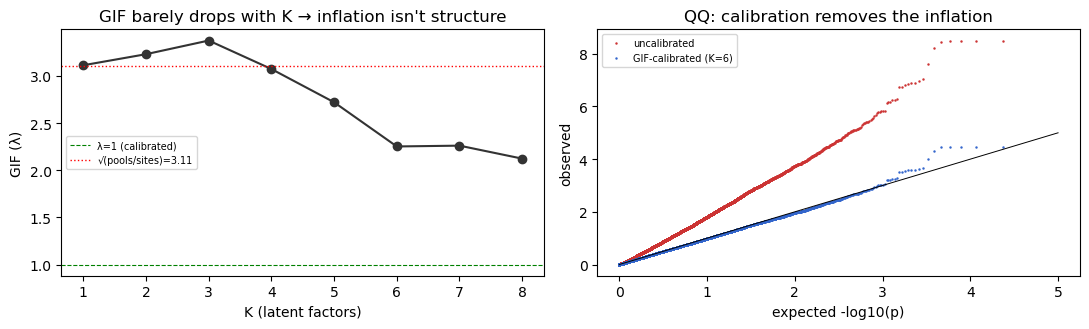

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
Ks = list(gif); ax[0].plot(Ks, [gif[k] for k in Ks], "o-", color="#333")
ax[0].axhline(1, color="g", ls="--", lw=.8, label="λ=1 (calibrated)")
ax[0].axhline(np.sqrt(n_pools/n_sites), color="r", ls=":", lw=1,
              label=f"√(pools/sites)={np.sqrt(n_pools/n_sites):.2f}")
ax[0].set_xlabel("K (latent factors)"); ax[0].set_ylabel("GIF (λ)")
ax[0].set_title("GIF barely drops with K → inflation isn't structure"); ax[0].legend(fontsize=7)
# QQ before vs after calibration
for p, lab, c in [(loci.unc_p, "uncalibrated", "#c33"), (loci.cal_p, f"GIF-calibrated (K={KDISP})", "#36c")]:
    o = -np.log10(np.sort(p.values)); e = -np.log10(np.linspace(1/len(o),1,len(o)))
    ax[1].plot(e, o, ".", ms=1.5, color=c, label=lab)
mx = 5; ax[1].plot([0,mx],[0,mx],"k-",lw=.7)
ax[1].set_xlabel("expected -log10(p)"); ax[1].set_ylabel("observed"); ax[1].legend(fontsize=7)
ax[1].set_title("QQ: calibration removes the inflation")
plt.tight_layout(); plt.show()

## Honest (GIF-calibrated) Manhattan

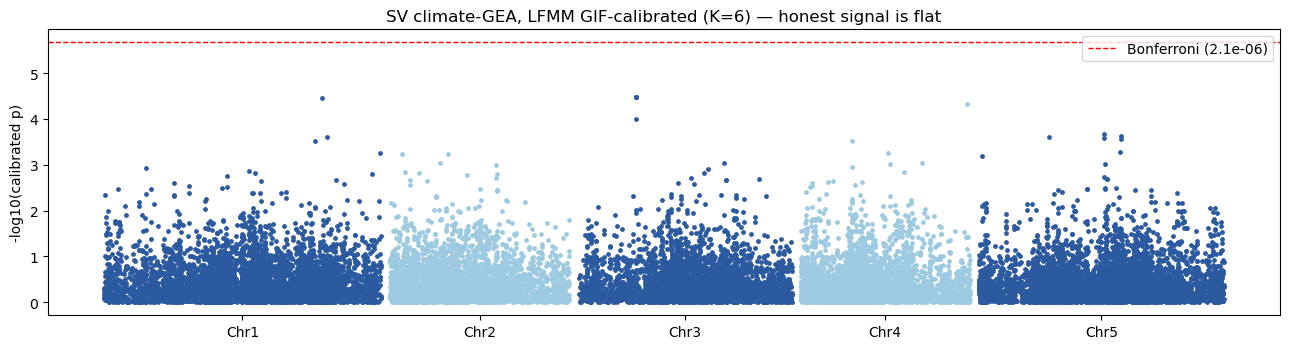

calibrated p<1e-4: 6 | Bonferroni hits: 0


In [3]:
# Honest (GIF-calibrated) Manhattan — compare to the naive Kendall's dense signal.
chrom_order=[f"Chr{i}" for i in range(1,6)]
loci["chrom"]=pd.Categorical(loci.chrom, chrom_order, ordered=True)
d=loci.sort_values(["chrom","pos"]).copy()
off,cum,ticks=({},0,[]); gap=1_000_000
for c in chrom_order:
    off[c]=cum; cmax=d.loc[d.chrom==c,"pos"].max(); ticks.append(cum+cmax/2); cum+=cmax+gap
d["gpos"]=d.pos+d.chrom.map(off).astype(float); d["mlogp"]=-np.log10(d.cal_p)
bonf=0.05/len(d)
fig,ax=plt.subplots(figsize=(13,3.6))
cols={"Chr1":"#2c5aa0","Chr2":"#9ecae1","Chr3":"#2c5aa0","Chr4":"#9ecae1","Chr5":"#2c5aa0"}
for c in chrom_order:
    s=d[d.chrom==c]; ax.scatter(s.gpos,s.mlogp,s=6,color=cols[c],rasterized=True)
ax.axhline(-np.log10(bonf),color="r",ls="--",lw=1,label=f"Bonferroni ({bonf:.1e})")
ax.set_xticks(ticks); ax.set_xticklabels(chrom_order)
ax.set_ylabel("-log10(calibrated p)"); ax.legend(loc="upper right")
ax.set_title(f"SV climate-GEA, LFMM GIF-calibrated (K={KDISP}) — honest signal is flat")
plt.tight_layout(); plt.show()
print(f"calibrated p<1e-4: {(d.cal_p<1e-4).sum()} | Bonferroni hits: {(d.cal_p<bonf).sum()}")

## Naive Kendall vs LFMM — the deflation

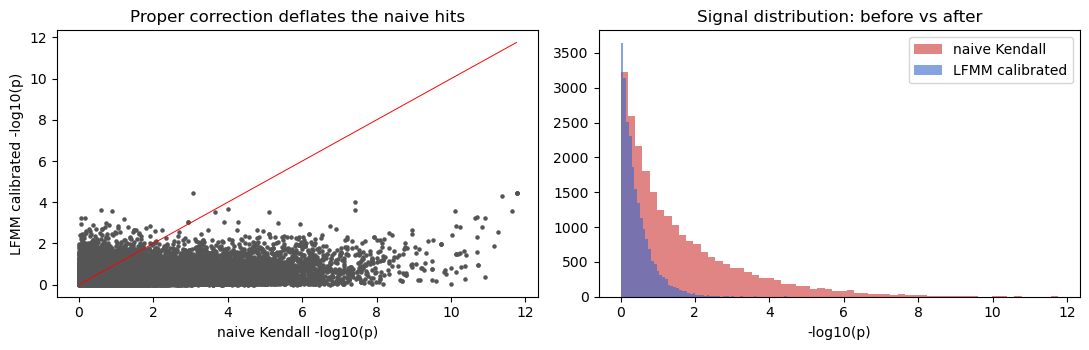

In [4]:
# Naive Kendall vs LFMM: how much the proper correction deflates each SV.
z=np.load(f"{GEA}/kendall_gen3_bio1.npz", allow_pickle=True)
kp=z["pval"][loci.rec_index.to_numpy()]          # Kendall p on the same loci
fig,ax=plt.subplots(1,2,figsize=(11,3.6))
ax[0].scatter(-np.log10(kp), -np.log10(loci.cal_p), s=5, color="#555", rasterized=True)
mx=max(np.nanmax(-np.log10(kp)),1); ax[0].plot([0,mx],[0,mx],"r-",lw=.7)
ax[0].set_xlabel("naive Kendall -log10(p)"); ax[0].set_ylabel("LFMM calibrated -log10(p)")
ax[0].set_title("Proper correction deflates the naive hits")
ax[1].hist(-np.log10(kp),bins=60,alpha=.6,label="naive Kendall",color="#c33")
ax[1].hist(-np.log10(loci.cal_p),bins=60,alpha=.6,label="LFMM calibrated",color="#36c")
ax[1].set_xlabel("-log10(p)"); ax[1].legend(); ax[1].set_title("Signal distribution: before vs after")
plt.tight_layout(); plt.show()

## Top LFMM hits (honest)

In [5]:
# Top LFMM hits (honest) — note they barely clear FDR.
m=len(loci); o=np.argsort(loci.cal_p.values); ranked=loci.cal_p.values[o]*m/np.arange(1,m+1)
q=np.minimum.accumulate(ranked[::-1])[::-1]; loci["bh_fdr"]=np.nan; loci.iloc[o, loci.columns.get_loc("bh_fdr")]=q
loci.sort_values("cal_p")[["chrom","pos","sv_size","p0","unc_p","cal_p","bh_fdr"]].head(20).reset_index(drop=True)

,chrom,pos,sv_size,p0,unc_p,cal_p,bh_fdr
0,Chr3,6366898,227,0.071090,3.141870e-09,0.000034,0.167732
1,Chr3,6365763,583,0.071090,3.141870e-09,0.000034,0.167732
2,Chr3,6367728,107,0.071090,3.141870e-09,0.000034,0.167732
3,Chr3,6366744,66,0.071090,3.141870e-09,0.000034,0.167732
4,Chr1,23984628,130,0.203893,3.533034e-09,0.000036,0.167732
5,Chr4,18273578,57,0.721668,5.901302e-09,0.000048,0.185291
6,Chr3,6367136,85,0.059092,2.405844e-08,0.000102,0.341505
7,Chr5,13801840,431,0.160270,9.411973e-08,0.000213,0.473822
8,Chr5,15643438,163,0.316229,1.121854e-07,0.000234,0.473822
9,Chr1,24474617,139,0.153782,1.274824e-07,0.000251,0.473822
